In [15]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tabulate import tabulate

    - Function to format results into a table

In [16]:
# Custom function to display tables in a formatted way
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

---

In [17]:
# Base directory where SVR results were saved
cache_dir = Path(r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_SVR_results")

# SVR test result folders
svr_paths = {"SVR Naive": cache_dir / "Tese_Bitcoin_Naive_test_rolling_step10_h120_pkl",
             "SVR Original": cache_dir / "Tese_Bitcoin_Variance_ret(L)_SVR_test_rolling_step10_h120_pkl",
             "SVR Logarithmic": cache_dir / "Tese_Bitcoin_Log-Variance_ret(L)_SVR_test_rolling_step10_h120_pkl",
             "SVR Yeo-Johnson": cache_dir / "Tese_Bitcoin_Yeo-Johnson-Variance_ret(L)_SVR_test_rolling_step10_h120_pkl"}

In [18]:
# Function to load SVR test results
def load_svr_test_result(model_name: str, folder_path: Path):
    """
    Load SVR test_results.parquet from a saved cache folder
    and add the model name.
    """

    test_file = folder_path / "test_results.parquet"

    if not test_file.exists():
        raise FileNotFoundError(f"File not found: {test_file}")

    df = pd.read_parquet(test_file).copy()
    df.insert(0, "Model", model_name)

    return df

In [19]:
# Load all SVR test results
svr_test_frames = []

for model_name, folder_path in svr_paths.items():
    df_tmp = load_svr_test_result(model_name, folder_path)
    svr_test_frames.append(df_tmp)

df_svr_all = pd.concat(svr_test_frames, ignore_index=True)

df_svr_compare_clean = df_svr_all.copy()

# Standardise model names, if needed
df_svr_compare_clean["Model"] = (df_svr_compare_clean["Model"].astype(str).replace({"SVR Naive": "Naive",
                                                                                    "SVR Original": "Original",
                                                                                    "SVR Logarithmic": "Logarithmic",
                                                                                    "SVR Yeo-Johnson": "Yeo-Johnson"}))

# Drop unnecessary Naive/benchmark-specific columns, if present
cols_to_drop = ["model", "variant", "m"]
df_svr_compare_clean = df_svr_compare_clean.drop(columns=cols_to_drop, errors="ignore")

# Ensure SVR configuration columns exist
config_cols = ["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]

for col in config_cols:
    if col not in df_svr_compare_clean.columns:
        df_svr_compare_clean[col] = np.nan

# Replace missing SVR configuration values with "-"
for col in config_cols:
    df_svr_compare_clean[col] = (df_svr_compare_clean[col].astype(object).where(df_svr_compare_clean[col].notna(), "-"))

# Set Model as index
df_svr_compare_clean = df_svr_compare_clean.set_index("Model")

# Order columns: SVR configuration first, then metrics
metric_cols = [c for c in df_svr_compare_clean.columns if c not in config_cols]

df_svr_compare_clean = df_svr_compare_clean[config_cols + metric_cols]

display_table(df_svr_compare_clean, "Loaded SVR test results - cleaned")


Loaded SVR test results - cleaned
╒═════════════╤══════════╤══════════╤═════╤═══════════╤═════════╤══════════╤═════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    Model    │  n_lags  │  kernel  │  C  │  epsilon  │  gamma  │  degree  │  coef0  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30   │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_

In [20]:
# Select RMSE columns
rmse_cols = sorted([c for c in df_svr_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

# Build clean comparison table
df_svr_rmse_compare = df_svr_all[["Model"] + rmse_cols + ["score_rmse_mean"] + ["score_qlike_mean"]].copy()

# Rename columns for thesis-style display
rename_cols = {"RMSE-h=1": "h=1", "RMSE-h=7": "h=7", "RMSE-h=15": "h=15", "RMSE-h=30": "h=30", "RMSE-h=120": "h=120", "score_rmse_mean": "Mean RMSE", "score_qlike_mean": "Mean QLIKE"}

df_svr_rmse_compare = df_svr_rmse_compare.rename(columns=rename_cols)

# Set model as index
df_svr_rmse_compare = df_svr_rmse_compare.set_index("Model")

display_table(df_svr_rmse_compare, "Comparative test performance of svr specifications across volatility-proxy representations")


Comparative test performance of svr specifications across volatility-proxy representations
╒═════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════════╤══════════════╕
│      Model      │    h=1     │    h=7     │    h=15    │    h=30    │   h=120    │  Mean RMSE  │   Mean QLIKE │
╞═════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════════╪══════════════╡
│    SVR Naive    │ 0.00102799 │ 0.00088119 │ 0.00075977 │ 0.00086042 │ 0.00090332 │ 0.00088654  │ 361.79743534 │
├─────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼─────────────┼──────────────┤
│  SVR Original   │ 0.00076419 │ 0.00044258 │ 0.00056931 │ 0.00058148 │ 0.00059529 │ 0.00059057  │  -5.03317852 │
├─────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼─────────────┼──────────────┤
│ SVR Logarithmic │ 0.00076496 │ 0.00047016 │ 0.00056788 │ 0.00057386 │ 0.00058856 │ 0.00059308  │  -4.7384234

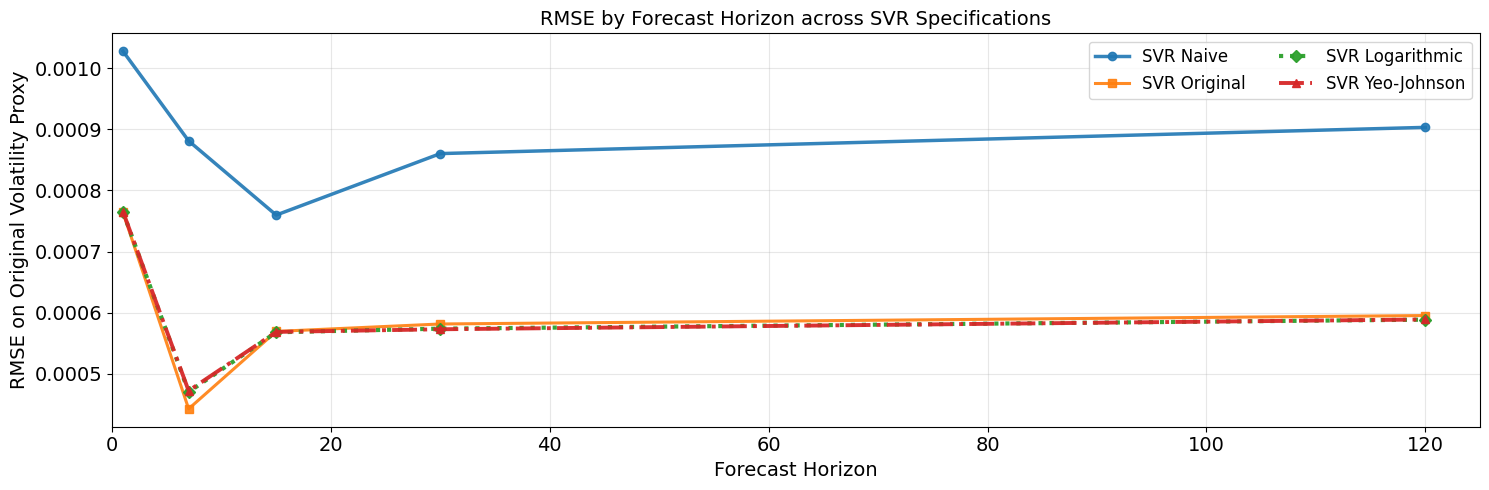

In [21]:
# Plot RMSE by forecast horizon for SVR specifications and Naive benchmark
def plot_svr_specifications_rmse(df_compare: pd.DataFrame):
    """
    Plot RMSE by forecast horizon for SVR specifications and Naive benchmark.
    """

    horizon_cols = [c for c in df_compare.columns if c.startswith("h=")]
    horizons = [int(c.split("=")[1]) for c in horizon_cols]

    plt.figure(figsize=(15, 5))

    plot_styles = {"Naive": {"marker": "o", "linestyle": "--", "linewidth": 2.5, "alpha": 0.9, "zorder": 1},
                   "SVR Original": {"marker": "s", "linestyle": "-", "linewidth": 2.2, "alpha": 0.9, "zorder": 3},
                   "SVR Logarithmic": {"marker": "D", "linestyle": ":", "linewidth": 3.0, "alpha": 0.95, "zorder": 4},
                   "SVR Yeo-Johnson": {"marker": "^", "linestyle": "-.", "linewidth": 2.8, "alpha": 0.95, "zorder": 5}}

    for model_name in df_compare.index:
        rmse_values = df_compare.loc[model_name, horizon_cols].astype(float).values

        style = plot_styles.get(model_name, {"marker": "o", "linestyle": "-", "linewidth": 2.5, "alpha": 0.9, "zorder": 2})

        plt.plot(horizons, rmse_values, label=model_name, marker=style["marker"], linestyle=style["linestyle"], linewidth=style["linewidth"],
                 alpha=style["alpha"], zorder=style["zorder"])

    plt.title("RMSE by Forecast Horizon across SVR Specifications", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)

    # X-axis like the reference plot
    plt.xticks(np.arange(0, 121, 20), fontsize=14)
    plt.xlim(0, 125)

    plt.yticks(fontsize=14)

    # Legend with two columns
    plt.legend(fontsize=12, loc="upper right", ncol=2, frameon=True)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_svr_specifications_rmse(df_svr_rmse_compare)